In this exercise, we will generate simulated data, and will then use this data to perform forward and backward stepwise selection.

In [4]:
import numpy as np
import pandas as pd
import itertools
import matplotlib.pyplot as plt
from sklearn.linear_model import LassoCV, Lasso
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error
import statsmodels.api as sm

**(a)** Create X and ε using normal distribution

In [7]:
rng = np.random.default_rng(0)

n = 100
X = rng.normal(size=n)
eps = rng.normal(size=n)

X[:5], eps[:5]

(array([ 0.12573022, -0.13210486,  0.64042265,  0.10490012, -0.53566937]),
 array([ 0.50268285,  0.98971303, -0.16429459, -1.07436486,  0.87304215]))

**(b)** Generate Y from  <br>
$Y = β0 + β1 X + β2 X² + β3 X³ + ε$

In [8]:
β0, β1, β2, β3 = 3, 2, -4, 5

Y = β0 + β1*X + β2*X**2 + β3*X**3 + eps
Y[:5]

array([3.70084871, 3.64416926, 3.7893045 , 2.09719086, 0.88540735])

**(c)** Forward Stepwise Selection using predictors X, X², …, X¹⁰
 We select the model minimizing Mallows' Cp.


In [10]:
# construct data matrix for predictors X^1 ... X^10
poly = PolynomialFeatures(10, include_bias=False)
X_poly = poly.fit_transform(X.reshape(-1, 1))
columns = [f"X^{i}" for i in range(1, 11)]
df = pd.DataFrame(X_poly, columns=columns)
df['Y'] = Y

# helper function to compute Cp
def cp(model, sigma2, n):
    rss = ((model.resid)**2).sum()
    p = model.df_model + 1
    return rss/sigma2 - (n - 2*p)

# compute sigma2 from full model
X_full = sm.add_constant(df[columns])
full_model = sm.OLS(Y, X_full).fit()
sigma2 = full_model.mse_resid

# forward selection
remaining = columns.copy()
selected = []
cp_values = []

while remaining:
    scores = []
    for cand in remaining:
        model_vars = selected + [cand]
        X_sel = sm.add_constant(df[model_vars])
        model = sm.OLS(Y, X_sel).fit()
        scores.append((cp(model, sigma2, n), cand))
    scores.sort()
    best_cp, best_var = scores[0]
    selected.append(best_var)
    remaining.remove(best_var)
    cp_values.append((best_cp, selected.copy()))

cp_values[-1], selected


((11.00000000000017,
  ['X^3', 'X^2', 'X^1', 'X^9', 'X^5', 'X^7', 'X^4', 'X^10', 'X^8', 'X^6']),
 ['X^3', 'X^2', 'X^1', 'X^9', 'X^5', 'X^7', 'X^4', 'X^10', 'X^8', 'X^6'])

In [11]:
best_model_vars = cp_values[np.argmin([c[0] for c in cp_values])][1]
model_forward = sm.OLS(Y, sm.add_constant(df[best_model_vars])).fit()
model_forward.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.996
Model:                            OLS   Adj. R-squared:                  0.996
Method:                 Least Squares   F-statistic:                     7967.
Date:                Tue, 02 Dec 2025   Prob (F-statistic):          6.26e-115
Time:                        09:53:35   Log-Likelihood:                -135.92
No. Observations:                 100   AIC:                             279.8
Df Residuals:                      96   BIC:                             290.3
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.9512      0.126     23.371      0.000       2.701       3.202
X^3            4.8898      0.070     69.693      0.000       4.751       5.029
X^2           -3.9995      0.088    -45.420      0.000      -4.174      -3.825
X^1            2.3043      0.190     12.126      0.000       1.927       2.681
==============================================================================
Omnibus:                        3.961   Durbin-Watson:                   2.121
Prob(Omnibus):                  0.138   Jarque-Bera (JB):                3.981
Skew:                          -0.464   Prob(JB):                        0.137
Kurtosis:                       2.695   Cond. No.                         5.73
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

**(d)** Backward Stepwise Selection using Cp

In [13]:
remaining = columns.copy()
cp_scores = []

while len(remaining) > 0:
    scores = []
    for var in remaining:
        trial = [v for v in remaining if v != var]
        X_sel = sm.add_constant(df[trial])
        model = sm.OLS(Y, X_sel).fit()
        scores.append((cp(model, sigma2, n), trial))
    scores.sort()
    best_cp, best_vars = scores[0]
    cp_scores.append((best_cp, best_vars))
    remaining = best_vars

cp_scores[0], cp_scores[-1]


((9.28233431417857,
  ['X^1', 'X^2', 'X^3', 'X^4', 'X^5', 'X^7', 'X^8', 'X^9', 'X^10']),
 (24065.092075985154, []))

In [14]:
best_backward_vars = cp_scores[np.argmin([c[0] for c in cp_scores])][1]
model_backward = sm.OLS(Y, sm.add_constant(df[best_backward_vars])).fit()
model_backward.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.996
Model:                            OLS   Adj. R-squared:                  0.996
Method:                 Least Squares   F-statistic:                     7967.
Date:                Tue, 02 Dec 2025   Prob (F-statistic):          6.26e-115
Time:                        09:54:26   Log-Likelihood:                -135.92
No. Observations:                 100   AIC:                             279.8
Df Residuals:                      96   BIC:                             290.3
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.9512      0.126     23.371      0.000       2.701       3.202
X^1            2.3043      0.190     12.126      0.000       1.927       2.681
X^2           -3.9995      0.088    -45.420      0.000      -4.174      -3.825
X^3            4.8898      0.070     69.693      0.000       4.751       5.029
==============================================================================
Omnibus:                        3.961   Durbin-Watson:                   2.121
Prob(Omnibus):                  0.138   Jarque-Bera (JB):                3.981
Skew:                          -0.464   Prob(JB):                        0.137
Kurtosis:                       2.695   Cond. No.                         5.73
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

**(e)** Fit Lasso with 10 polynomial predictors and use cross-validation to choose λ.
Plot CV error and report coefficients.


/opt/conda/envs/anaconda-ai-2024.04-py310/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:614: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 11.527750927482884, tolerance: 2.1751999090646614
  model = cd_fast.enet_coordinate_descent_gram(
/opt/conda/envs/anaconda-ai-2024.04-py310/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:614: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 17.123794631775127, tolerance: 2.1751999090646614
  model = cd_fast.enet_coordinate_descent_gram(
/opt/conda/envs/anaconda-ai-2024.04-py310/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:614: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 2.4427771201553696, tolerance: 1.4225652665379391
  model = cd_fast.enet_coordinate_descent_gram(
/opt

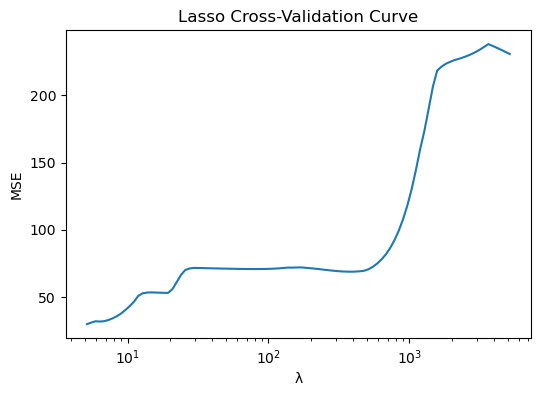

(5.160296378373306,
 array([ 0.        , -0.        ,  0.        , -0.        ,  1.4956659 ,
        -0.        ,  0.15451455, -0.03822925, -0.0523143 , -0.        ]))

In [23]:
lasso_cv = LassoCV(cv=10, random_state=0)
lasso_cv.fit(X_poly, Y)

plt.figure(figsize=(6,4))
plt.plot(lasso_cv.alphas_, lasso_cv.mse_path_.mean(axis=1))
plt.xscale('log')
plt.xlabel("λ")
plt.ylabel("MSE")
plt.title("Lasso Cross-Validation Curve")
plt.show()

lasso_cv.alpha_, lasso_cv.coef_


**(f)** Generate new Y using only X⁷.Run forward selection and lasso again and compare.

In [24]:
β0_new = 5
β7_new = 10

Y2 = β0_new + β7_new*(X**7) + eps
df2 = df.copy()
df2["Y2"] = Y2

remaining = columns.copy()
selected = []
cp2_list = []

# new sigma2 from full model
full_model2 = sm.OLS(Y2, sm.add_constant(df2[columns])).fit()
sigma2_2 = full_model2.mse_resid

while remaining:
    scores = []
    for cand in remaining:
        model_vars = selected + [cand]
        X_sel = sm.add_constant(df2[model_vars])
        model = sm.OLS(Y2, X_sel).fit()
        scores.append((cp(model, sigma2_2, n), cand))
    scores.sort()
    best_cp, best_var = scores[0]
    selected.append(best_var)
    remaining.remove(best_var)
    cp2_list.append((best_cp, selected.copy()))

selected


['X^7', 'X^1', 'X^5', 'X^4', 'X^3', 'X^9', 'X^10', 'X^8', 'X^2', 'X^6']

In [25]:
lasso_cv2 = LassoCV(cv=10, random_state=1)
lasso_cv2.fit(X_poly, Y2)

lasso_cv2.alpha_, lasso_cv2.coef_


(777.0807973183931,
 array([0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 2.27297016, 0.15923286]))